# Text Mining Assignment 1

### Loading Dataset

In [1]:
from sklearn.datasets import fetch_20newsgroups

categories = [
    "alt.atheism",
    "comp.graphics", 
    "comp.os.ms-windows.misc", 
    "comp.sys.ibm.pc.hardware", 
    "comp.sys.mac.hardware", 
    "comp.windows.x", 
    "misc.forsale", 
    "rec.autos", 
    "rec.motorcycles", 
    "rec.sport.baseball", 
    "rec.sport.hockey", 
    "sci.crypt", 
    "sci.electronics",
    "sci.med", 
    "sci.space", 
    "soc.religion.christian", 
    "talk.politics.guns", 
    "talk.politics.mideast", 
    "talk.politics.misc",
    "talk.religion.misc",
]


def size_mb(docs):
    return sum(len(s.encode("utf-8")) for s in docs) / 1e6

First we load the dataset utilising the heuristics provided by sklearn to remove message metadata:

In [2]:
from time import time

data_train = fetch_20newsgroups(
    subset="train",
    categories=categories,
    shuffle=True,
    random_state=42,
    remove=("headers", "footers", "quotes"),
)

data_test = fetch_20newsgroups(
    subset="test",
    categories=categories,
    shuffle=True,
    random_state=42,
    remove=("headers", "footers", "quotes"),
)

target_names = data_train.target_names

data_train_size_mb = size_mb(data_train.data)
data_test_size_mb = size_mb(data_test.data)

print(
    f"{len(data_train.data)} documents - "
    f"{data_train_size_mb:.2f}MB (training set)"
)
print(f"{len(data_test.data)} documents - {data_test_size_mb:.2f}MB (test set)")
print(f"{len(target_names)} categories")

11314 documents - 13.78MB (training set)
7532 documents - 8.26MB (test set)
20 categories


Since the targets/labels doesn't need to get vectorized, we can extract them now.

In [3]:
y_train, y_test = data_train.target, data_test.target

### Vectorizer Function

Next we define a function to vectorize the train and test data based on three types of features: count, tf, and tf-idf. 

In [4]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

def vectorize_dataset(data_train, data_test, feature="count", **vectorizer_params):
    """ Vectorise dataset based on certain feature.
    
    Args:
        feature: "count", "tf", or "tfidf". Decides which sklearn vectorizer is used. 
        vectorizer_params: optional params passed to the sklearn vectorizer.
    
    Returns:
        vectorised train and test datasets, the feature names, and the vectorizer used.
    """
    if feature == "count":
        vectorizer = CountVectorizer(**vectorizer_params)
    elif feature == "tf":
        vectorizer = TfidfVectorizer(use_idf=False, **vectorizer_params)
    elif feature == "tfidf":
        vectorizer = TfidfVectorizer(use_idf=True, **vectorizer_params)
    else:
        raise ValueError(f"feature must be 'count', 'tf' or 'tfidf', got {feature}")
        
    
    t0 = time()
    X_train = vectorizer.fit_transform(data_train.data)
    duration_train = time() - t0
    
    t0 = time()
    X_test = vectorizer.transform(data_test.data)
    duration_test = time() - t0
    
    feature_names = vectorizer.get_feature_names_out()
    
    print(
        f"vectorizing train_dataset done in {duration_train:.3f}s "
        f"at {data_train_size_mb / duration_train:.3f}MB/s"
    )
    print(f"n_samples: {X_train.shape[0]}, n_features: {X_train.shape[1]}")
    print(
        f"vectorizing test_dataset done in {duration_test:.3f}s "
        f"at {data_test_size_mb / duration_test:.3f}MB/s"
    )
    print(f"n_samples: {X_test.shape[0]}, n_features: {X_test.shape[1]}")
    
    return X_train, X_test, feature_names, vectorizer

### Comparing Classifiers 

In this section we will compare three classification models. Since it is not specified in the assignment, we will use the TfidfVectorizer with the same parameters as the tutorial when comparing the classifiers. 

In [5]:
X_train, X_test, feature_names, vectorizer = vectorize_dataset(data_train, data_test, "tfidf", sublinear_tf=True, max_df=0.5, min_df=5, stop_words="english")

vectorizing train_dataset done in 0.878s at 15.699MB/s
n_samples: 11314, n_features: 17797
vectorizing test_dataset done in 0.419s at 19.727MB/s
n_samples: 7532, n_features: 17797


The three models we will compare will be Logistic Regression, K-Nearest Neighbor, and LinearSVC.

In [6]:
from sklearn import metrics
from sklearn.utils.extmath import density

def benchmark(clf, X_train, X_test, y_train=y_train, y_test=y_test, custom_name=False):
    """Fit clf on the train data and evaluate it on the test data.

    Args:
        clf: unfitted scikit-learn classifier.
        X_train, X_test: training and testing features.
        y_train y_test: training and testing labels.
        custom_name: label for the results table (defaults to the class name).

    Returns:
        dict with name, accuracy, macro precision/recall/F1, and train/test times.
    """
    print("_" * 80)
    print("Training: ")
    print(clf)
    t0 = time()
    clf.fit(X_train, y_train)
    train_time = time() - t0
    print(f"train time: {train_time:.3f}s")

    t0 = time()
    pred = clf.predict(X_test)
    test_time = time() - t0
    print(f"test time:  {test_time:.3f}s")

    score = metrics.accuracy_score(y_test, pred)
    print(f"accuracy:   {score:.3f}")
    
    p, r, f1, _ = metrics.precision_recall_fscore_support(
       y_test, pred, average="macro", zero_division=0
    )
    print(f"precision:  {p:.3f}")
    print(f"recall:  {r:.3f}")
    print(f"f1:  {f1:.3f}")

    if hasattr(clf, "coef_"):
        print(f"dimensionality: {clf.coef_.shape[1]}")
        print(f"density: {density(clf.coef_)}")
        print()

    print()
    result = {
        "name": custom_name or clf.__class__.__name__,
        "accuracy": metrics.accuracy_score(y_test, pred),
        "precision": p,
        "recall": r,
        "f1": f1,
        "train_time": train_time,
        "test_time": test_time,
    }
    return result

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC

results = []
for clf, name in (
    (LogisticRegression(C=5, max_iter=1000), "Logistic Regression"),
    (KNeighborsClassifier(n_neighbors=1000), "kNN"),
    # L2 penalty Linear SVC
    (LinearSVC(C=0.1, dual=False, max_iter=1000), "Linear SVC")
):
    print("=" * 80)
    print(name)
    results.append(benchmark(clf, X_train, X_test, custom_name=name))


Logistic Regression
________________________________________________________________________________
Training: 
LogisticRegression(C=5, max_iter=1000)
train time: 8.621s
test time:  0.009s
accuracy:   0.683
precision:  0.682
recall:  0.672
f1:  0.673
dimensionality: 17797
density: 1.0


kNN
________________________________________________________________________________
Training: 
KNeighborsClassifier(n_neighbors=1000)
train time: 0.015s
test time:  1.511s
accuracy:   0.611
precision:  0.656
recall:  0.593
f1:  0.582

Linear SVC
________________________________________________________________________________
Training: 
LinearSVC(C=0.1, dual=False)
train time: 5.544s
test time:  0.006s
accuracy:   0.695
precision:  0.693
recall:  0.680
f1:  0.678
dimensionality: 17797
density: 1.0




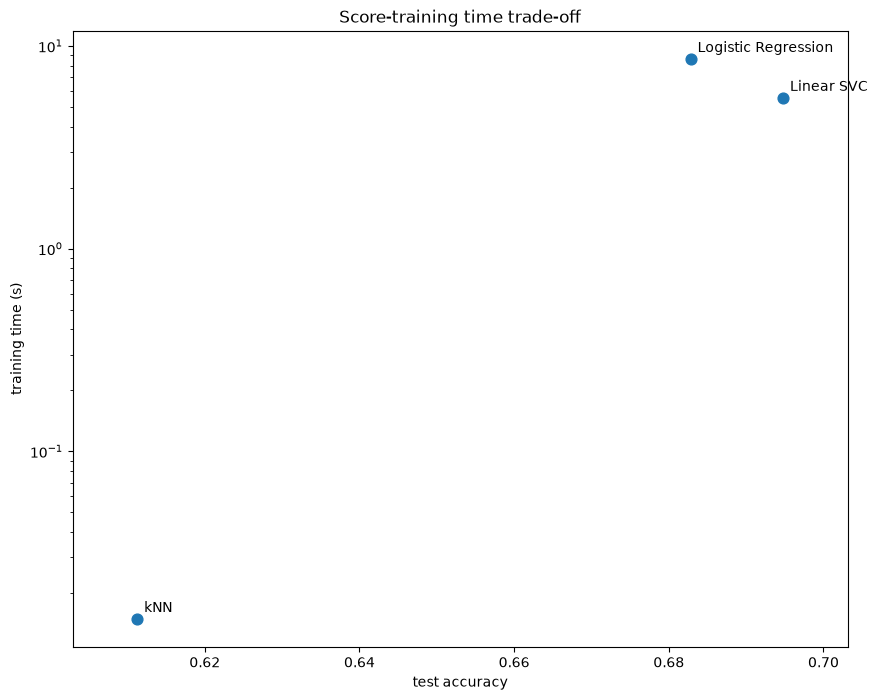

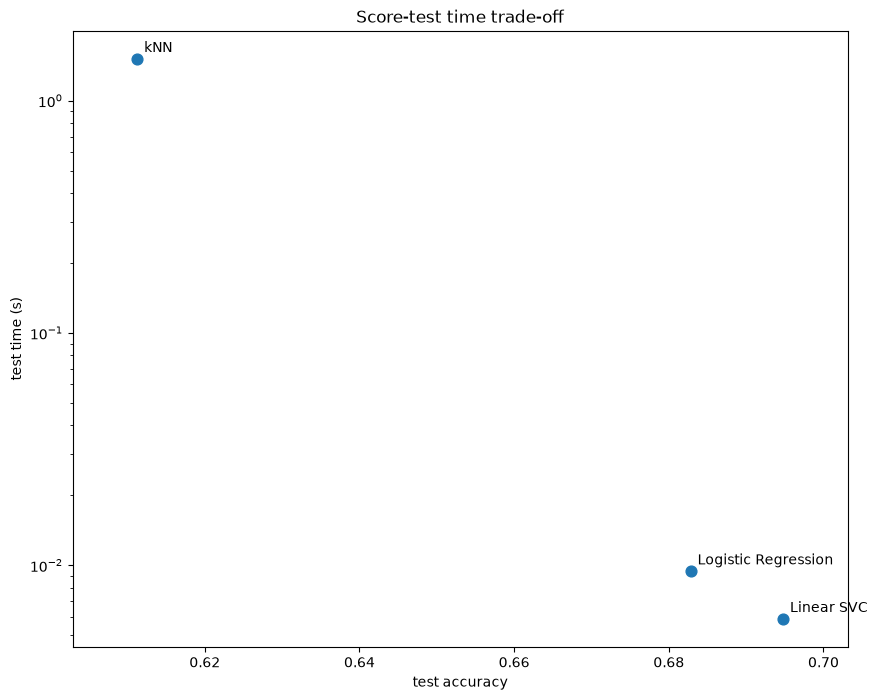

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(results)

def tradeoff_plot(df, time_col, title, ylabel):
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.scatter(df["accuracy"], df[time_col], s=60)
    ax.set(title=title, yscale="log", xlabel="test accuracy", ylabel=ylabel)
    for _, row in df.iterrows():
        ax.annotate(row["name"], (row["accuracy"], row[time_col]),
                    xytext=(5, 5), textcoords="offset points")
    ax.margins(x=0.1)
    return fig

tradeoff_plot(df, "train_time", "Score-training time trade-off", "training time (s)")
tradeoff_plot(df, "test_time", "Score-test time trade-off", "test time (s)")
plt.show()

### Comparing Features (count, tf, tfidf) Across Classifiers

In this section we will compare three features i.e. methods of vectorising the train/test datasets, by using the three classification models from the previous section. First lets use the CountVectorizer:

In [9]:
X_train_count, X_test_count, _, _ = vectorize_dataset(data_train, data_test, "count", max_df=0.5, min_df=5, stop_words="english")
X_train_tf, X_test_tf, _, _ = vectorize_dataset(data_train, data_test, "tf", sublinear_tf=True, max_df=0.5, min_df=5, stop_words="english")
X_train_tfidf, X_test_tfidf, _, _ = vectorize_dataset(data_train, data_test, "tfidf", sublinear_tf=True, max_df=0.5, min_df=5, stop_words="english")

vectorizing train_dataset done in 0.757s at 18.212MB/s
n_samples: 11314, n_features: 17797
vectorizing test_dataset done in 0.458s at 18.048MB/s
n_samples: 7532, n_features: 17797
vectorizing train_dataset done in 0.809s at 17.042MB/s
n_samples: 11314, n_features: 17797
vectorizing test_dataset done in 0.419s at 19.699MB/s
n_samples: 7532, n_features: 17797
vectorizing train_dataset done in 0.698s at 19.738MB/s
n_samples: 11314, n_features: 17797
vectorizing test_dataset done in 0.390s at 21.186MB/s
n_samples: 7532, n_features: 17797


In [13]:
classifiers = {
    "Logistic Regression": LogisticRegression(C=5, max_iter=1000),
    "kNN": KNeighborsClassifier(n_neighbors=1000),
    "Linear SVC": LinearSVC(C=0.1, dual=False, max_iter=1000),
}

vectorized_datasets = [
    ("count", X_train_count, X_test_count),
    ("tf", X_train_tf, X_test_tf),
    ("tfidf", X_train_tfidf, X_test_tfidf),
]

results = []
for name, clf in classifiers.items():
    for feature, X_train, X_test in vectorized_datasets:
        print(feature)
        result = benchmark(clf, X_train, X_test, custom_name=name)
        result["feature"] = feature
        results.append(result)
        
df = pd.DataFrame(results)

count
________________________________________________________________________________
Training: 
LogisticRegression(C=5, max_iter=1000)
train time: 14.685s
test time:  0.017s
accuracy:   0.601
precision:  0.602
recall:  0.592
f1:  0.594
dimensionality: 17797
density: 1.0


tf
________________________________________________________________________________
Training: 
LogisticRegression(C=5, max_iter=1000)
train time: 14.394s
test time:  0.018s
accuracy:   0.655
precision:  0.654
recall:  0.644
f1:  0.645
dimensionality: 17797
density: 1.0


tfidf
________________________________________________________________________________
Training: 
LogisticRegression(C=5, max_iter=1000)
train time: 8.226s
test time:  0.016s
accuracy:   0.683
precision:  0.682
recall:  0.672
f1:  0.673
dimensionality: 17797
density: 1.0


count
________________________________________________________________________________
Training: 
KNeighborsClassifier(n_neighbors=1000)
train time: 0.005s
test time:  1.464s
accu

/mnt/c/Users/Dom/desktop/coding/text_mining_leiden/TextMining/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1295: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


train time: 78.109s
test time:  0.009s
accuracy:   0.627
precision:  0.623
recall:  0.616
f1:  0.617
dimensionality: 17797
density: 1.0


tf
________________________________________________________________________________
Training: 
LinearSVC(C=0.1, dual=False)
train time: 1.449s
test time:  0.007s
accuracy:   0.669
precision:  0.665
recall:  0.654
f1:  0.651
dimensionality: 17797
density: 1.0


tfidf
________________________________________________________________________________
Training: 
LinearSVC(C=0.1, dual=False)
train time: 1.348s
test time:  0.007s
accuracy:   0.695
precision:  0.693
recall:  0.680
f1:  0.678
dimensionality: 17797
density: 1.0




In [14]:
print(df)

                  name  accuracy  precision    recall        f1  train_time  \
0  Logistic Regression  0.601434   0.601918  0.591765  0.593583   14.685292   
1  Logistic Regression  0.655204   0.653507  0.643686  0.644751   14.393595   
2  Logistic Regression  0.682820   0.681712  0.671771  0.672832    8.226428   
3                  kNN  0.115109   0.590299  0.109980  0.082689    0.005473   
4                  kNN  0.530005   0.593779  0.513484  0.503446    0.002109   
5                  kNN  0.611259   0.655609  0.592617  0.582039    0.002368   
6           Linear SVC  0.627058   0.622962  0.616295  0.616581   78.108860   
7           Linear SVC  0.668747   0.665422  0.654057  0.651085    1.449100   
8           Linear SVC  0.694769   0.693272  0.680219  0.677592    1.348320   

   test_time feature  
0   0.016911   count  
1   0.017694      tf  
2   0.015987   tfidf  
3   1.463741   count  
4   1.364937      tf  
5   1.138355   tfidf  
6   0.008718   count  
7   0.006860      tf  
8 

### TfidfVectorizer Params Experimentation

In this section we will narrow in on the TfidfVectorizer, experimenting with its different parameters to see which one performs the best.